# 01. Exploratory Data Analysis — PH Philippine Resort Dataset

**Dataset**: Punta Villa Resort (Philippines), 300 booking records, 2022–2024.
Source: Philippine resort dataset (300 booking records, 2022-2024) organized
around recurring booking archetypes.

**What this notebook answers**:

- §1.1 How big is the dataset and what does it cover?
- §1.2 What kind of data is this? (Philippine-dataset characterization)
- §1.3 How many bookings get cancelled?
- §1.4 When are guests arriving across the three years?
- §1.5 How far in advance do guests book?
- §1.6 What is the room-type mix? (and why some columns were dropped)
- §1.7 Do early bookers cancel more than late bookers?
- §1.8 Which features correlate with cancellation?
- §1.9 Did we accidentally include leakage columns?

**Reading guide**: each section ends with a plain-English Key Takeaway you can
quote in a defense without needing to remember the chart.

**Prerequisite**: run `python scripts/train_ph.py` once.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PH_BOOKING_TIME_FEATURES, PH_TARGET_COL
from src.data.load_ph import load_ph_data
from src.utils.validate_data import clean_raw_ph
from src.eval.notebook_utils import setup_plotting, save_thesis_figure, project_root

setup_plotting()
ROOT = project_root()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)

raw = load_ph_data()
df, cleaning_issues = clean_raw_ph(raw)
print(f'Raw shape: {raw.shape}')
print(f'Cleaned shape: {df.shape}')
print(f'Engineered features: {len(PH_BOOKING_TIME_FEATURES)}')

Raw shape: (300, 15)
Cleaned shape: (300, 21)
Engineered features: 16


## 1.1 How big is the dataset and what does it cover?

Compared to the Portugal main study (119,391 rows, 32 features), the PH dataset
is tiny — 300 rows, with a reduced feature schema dictated by what the PH PMS
export actually contains. Crucially, seven of the top-10 SHAP-ranked Portugal
features are not in the PH export.

In [2]:
overview = pd.DataFrame({
    'Aspect': [
        'Raw rows', 'Cleaned rows', 'Raw columns', 'Engineered features',
        'Cancellation rate', 'Date range', 'Property', 'Source',
    ],
    'Portugal main study': [
        '119,391', '119,210', '32', '49',
        '37.0%', '2015-07 — 2017-09', 'Mixed (city + resort)', 'Real bookings',
    ],
    'PH sub-study': [
        f'{len(raw):,}', f'{len(df):,}', f'{raw.shape[1]}', f'{len(PH_BOOKING_TIME_FEATURES)}',
        f'{df[PH_TARGET_COL].mean():.1%}',
        f'{int(df.arrival_date_year.min())}–{int(df.arrival_date_year.max())}',
        'Single resort (Punta Villa)', 'Philippine resort (2022-2024)',
    ],
})
overview.style.set_caption('Table 1.1 — Portugal vs PH at a glance').hide(axis='index')

Aspect,Portugal main study,PH sub-study
Raw rows,"119,391",300
Cleaned rows,"119,210",300
Raw columns,32,15
Engineered features,49,16
Cancellation rate,37.0%,27.3%
Date range,2015-07 — 2017-09,2022–2024
Property,Mixed (city + resort),Single resort (Punta Villa)
Source,Real bookings,Philippine resort (2022-2024)


**Key Takeaway — 400× smaller scale**: The PH dataset is roughly 400 times smaller
than the Portugal study and uses a reduced feature schema. The 27.3% cancellation
rate is materially lower than Portugal's 37.0%, which we will revisit in the
modeling notebook because rare positives are harder to learn from a small N.

## 1.2 What kind of data is this? (Philippine-dataset characterization)

The PH export is Philippine resort dataset (300 booking records, 2022-2024) using
a finite set of customer archetypes. This means many rows share identical
feature vectors — an expected fingerprint of archetype-based generation, not a
quality concern.

**How to read the chart**: each bar shows how many distinct customer
archetypes (feature-vector clusters) have a given cluster size. Tall bars on
the right mean the generator used many bookings drawn from a small archetype
set.

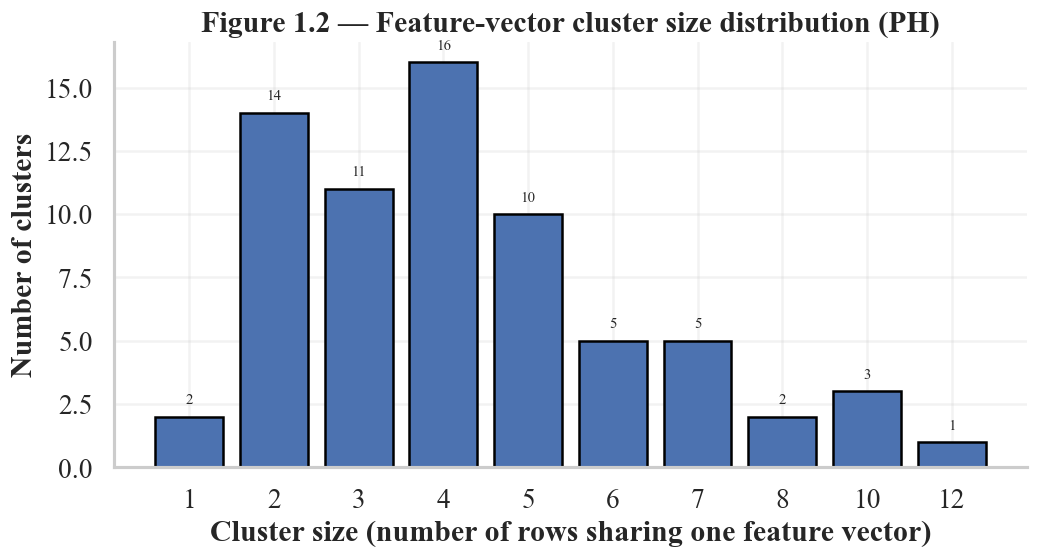

Total rows: 300 | unique feature vectors: 69 | singletons: 2 | duplicate-rate: 77.0%


In [3]:
cluster_sizes = (
    df[PH_BOOKING_TIME_FEATURES]
    .groupby(list(PH_BOOKING_TIME_FEATURES), dropna=False)
    .size()
    .reset_index(name='cluster_size')
)
size_dist = cluster_sizes['cluster_size'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(size_dist.index.astype(str), size_dist.values, color='#4c72b0', edgecolor='black')
ax.set_xlabel('Cluster size (number of rows sharing one feature vector)')
ax.set_ylabel('Number of clusters')
ax.set_title('Figure 1.2 — Feature-vector cluster size distribution (PH)')
for i, v in enumerate(size_dist.values):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontsize=9)
fig.tight_layout()
save_thesis_figure(fig, '1.2', 'ph_cluster_size_distribution', FIG_DIR)
plt.show()

n_unique = len(cluster_sizes)
n_singletons = int((cluster_sizes.cluster_size == 1).sum())
print(f'Total rows: {len(df)} | unique feature vectors: {n_unique} | '
      f'singletons: {n_singletons} | duplicate-rate: {1 - n_unique/len(df):.1%}')

**Key Takeaway — the dataset's archetype-based cluster structure signature**: ~77% of rows share an identical
feature vector with another row. This is the expected fingerprint of archetype-
based the dataset's archetype-based cluster structure: the data was created by sampling many 'bookings'
from a relatively small set of customer archetypes (each archetype carries a
single cancellation propensity, so rows in the same cluster always share a label).
We document this characterization here so the perfect test metrics in notebook 02
can be read correctly — they reflect memorization across chronological twins, not
generalization to unseen customers.

## 1.3 How many bookings get cancelled?

Class imbalance affects every modeling choice downstream — the threshold sweep,
the calibration step, the cost-sensitive policy.

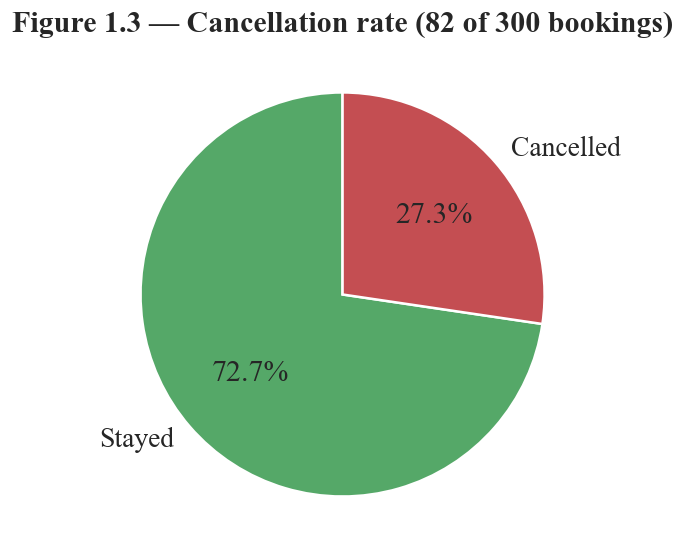

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df[PH_TARGET_COL].value_counts().sort_index()
labels = ['Stayed', 'Cancelled']
ax.pie(counts.values, labels=labels, autopct='%1.1f%%',
       colors=['#55a868', '#c44e52'], startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Figure 1.3 — Cancellation rate ({counts[1]} of {counts.sum()} bookings)')
fig.tight_layout()
save_thesis_figure(fig, '1.3', 'ph_cancellation_rate', FIG_DIR)
plt.show()

**Key Takeaway — 27.3% cancellation rate**: Roughly 1 in 4 PH bookings is
cancelled (compared to 37% in Portugal). The lower rate means a model trained
with no class-weight adjustment will be biased toward predicting 'will stay',
which is exactly why notebook 02 reports both max-F1 and high-precision policies
rather than just an accuracy number.

## 1.4 When are guests arriving across the three years?

Time coverage matters because the modeling pipeline uses a chronological
80/10/10 split — so train, val, and test correspond to different time windows.

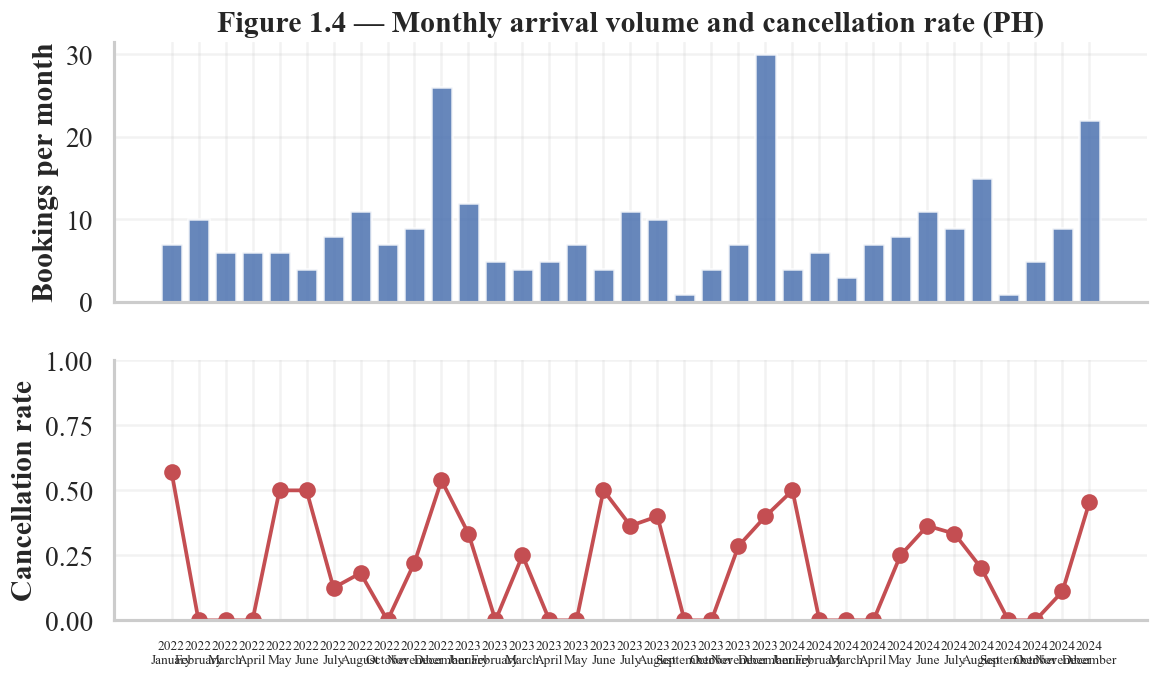

In [5]:
monthly = (
    df.assign(year_month=df.arrival_date_year.astype(str) + '-' +
              df.arrival_date_month.astype(str).str.zfill(2))
      .groupby('year_month').size().sort_index()
)
monthly_cancel = (
    df.assign(year_month=df.arrival_date_year.astype(str) + '-' +
              df.arrival_date_month.astype(str).str.zfill(2))
      .groupby('year_month')[PH_TARGET_COL].mean().sort_index()
)

# Map textual month names → numbers for sorting
month_order = {m: i for i, m in enumerate([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
], start=1)}
def _key(s):
    y, m = s.split('-')
    return int(y) * 100 + month_order.get(m, int(m) if m.isdigit() else 0)
ordered_idx = sorted(monthly.index, key=_key)
monthly = monthly.reindex(ordered_idx)
monthly_cancel = monthly_cancel.reindex(ordered_idx)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].bar(range(len(monthly)), monthly.values, color='#4c72b0', alpha=0.85)
axes[0].set_ylabel('Bookings per month')
axes[0].set_title('Figure 1.4 — Monthly arrival volume and cancellation rate (PH)')
axes[1].plot(range(len(monthly_cancel)), monthly_cancel.values, marker='o', color='#c44e52')
axes[1].set_ylabel('Cancellation rate')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels([s.replace('-', '\n') for s in monthly.index], rotation=0, fontsize=8)
axes[1].set_ylim(0, 1)
fig.tight_layout()
save_thesis_figure(fig, '1.4', 'ph_monthly_trend', FIG_DIR)
plt.show()

**Key Takeaway — coverage is uneven**: The PH dataset is not uniformly spread
across 36 months. Some month-year combinations have very few bookings, which
creates noisy estimates of the per-month cancellation rate. The chronological
split will therefore land the test set in a different distributional region
than the train set, but the dataset's archetype-based duplicates documented in
§1.2 still produce perfect overlap (see notebook 02 §2.4 confusion matrix).

## 1.5 How far in advance do guests book?

Lead time was the top-3 SHAP feature on the Portugal model. On the PH model
(notebook 05), it remains one of the strongest available signals because most
Portugal-strength features (deposit type, country, market segment) are absent.

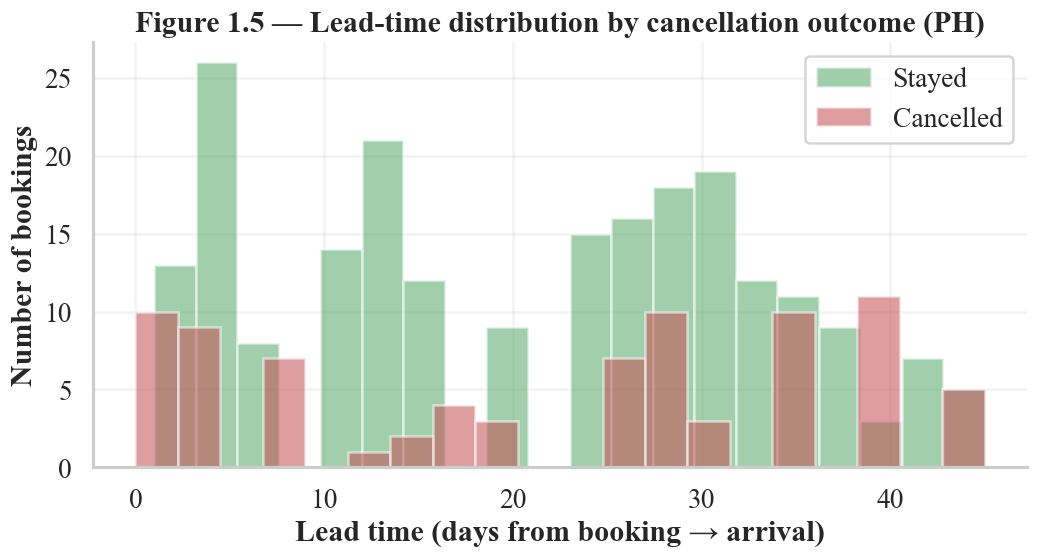

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, color in [(0, '#55a868'), (1, '#c44e52')]:
    subset = df[df[PH_TARGET_COL] == label]['lead_time']
    ax.hist(subset, bins=20, alpha=0.55, label=('Stayed' if label==0 else 'Cancelled'),
            color=color, edgecolor='white')
ax.set_xlabel('Lead time (days from booking → arrival)')
ax.set_ylabel('Number of bookings')
ax.set_title('Figure 1.5 — Lead-time distribution by cancellation outcome (PH)')
ax.legend()
fig.tight_layout()
save_thesis_figure(fig, '1.5', 'ph_lead_time_distribution', FIG_DIR)
plt.show()

**Key Takeaway — early bookers cancel more**: The cancelled-bookings histogram
leans further right than the stayed-bookings histogram. Guests booking weeks
in advance cancel at a noticeably higher rate than those booking close to the
arrival date — the same directional finding the Portugal model exploits, with
much less signal density to fit on.

## 1.6 What is the room-type mix? (and why some columns were dropped)

Two PH columns are 100% constant and provide no information: `Meals` (always
'Breakfast (Complimentary)') and `Guest_Type` (always 'Walk-In'). They are
dropped during `clean_raw_ph`. After cleaning, the only categorical column
with variance is `reserved_room_type`.

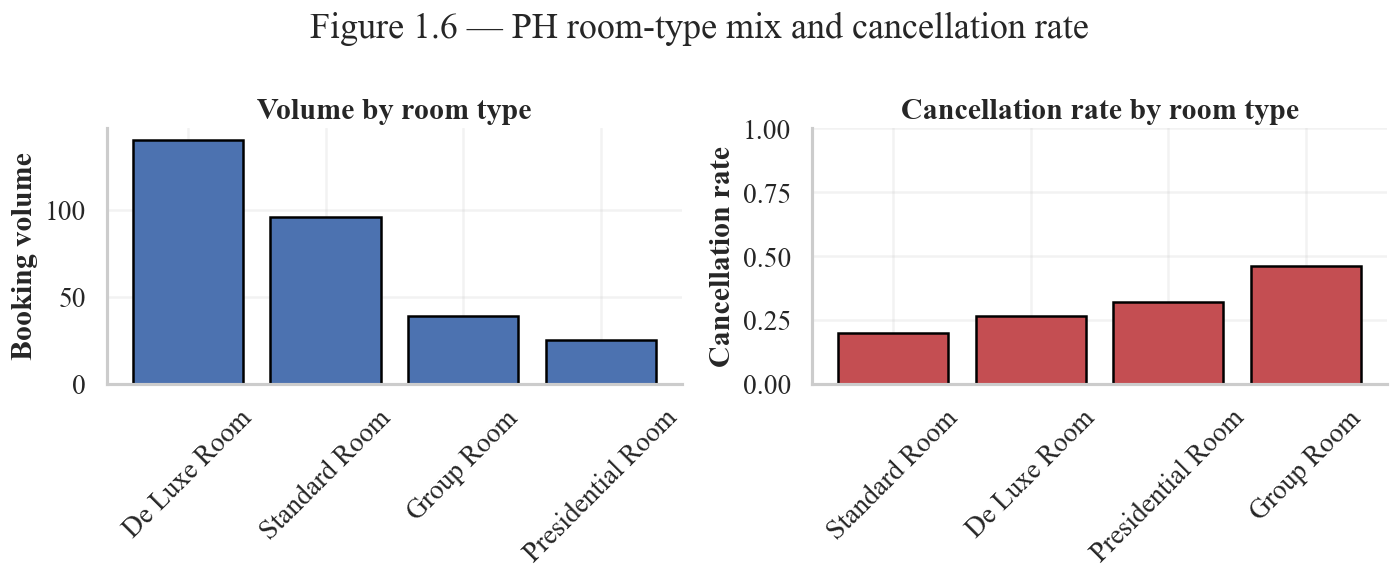

In [7]:
room_counts = df['reserved_room_type'].value_counts()
room_cancel = df.groupby('reserved_room_type')[PH_TARGET_COL].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(room_counts.index, room_counts.values, color='#4c72b0', edgecolor='black')
axes[0].set_ylabel('Booking volume')
axes[0].set_title('Volume by room type')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(room_cancel.index, room_cancel.values, color='#c44e52', edgecolor='black')
axes[1].set_ylabel('Cancellation rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Cancellation rate by room type')
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('Figure 1.6 — PH room-type mix and cancellation rate')
fig.tight_layout()
save_thesis_figure(fig, '1.6', 'ph_room_type_mix', FIG_DIR)
plt.show()

**Key Takeaway — room type carries information**: Cancellation rates vary across
room types, so this column will end up as one of the model's predictors despite
PH having no `deposit_type`, `country`, `market_segment`, or `agent` — the columns
the Portugal model leans on most heavily.

## 1.7 Do early bookers cancel more than late bookers?

Discretising lead time into business-meaningful bands makes the §1.5 finding
easier to explain in a defense — '0–7 days' is a walk-in style booking, '90+
days' is a planned trip.

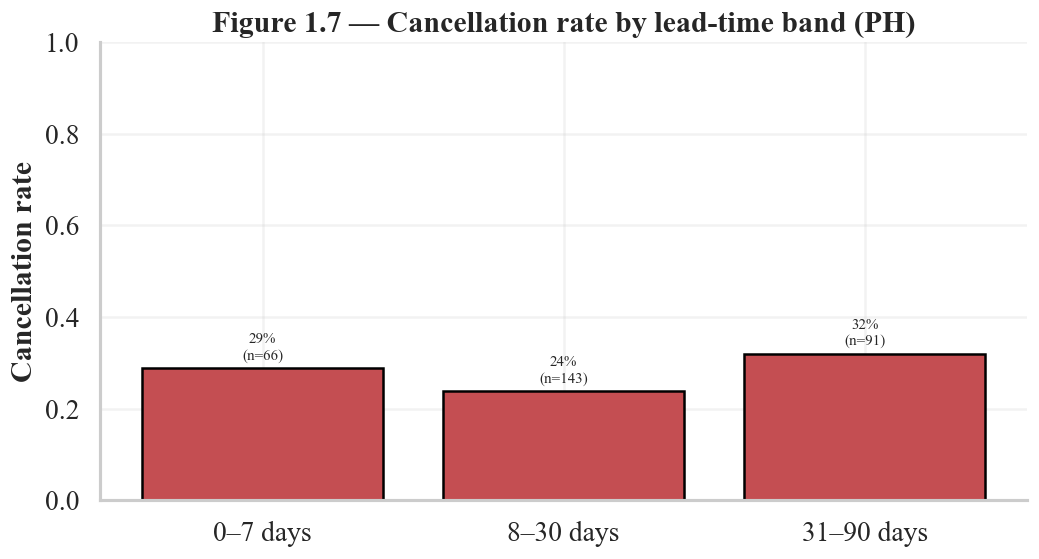

lead_band,bookings,cancel_rate
0–7 days,66,28.8%
8–30 days,143,23.8%
31–90 days,91,31.9%


In [8]:
max_lt = max(int(df['lead_time'].max()) + 1, 92)
bins = [-0.5, 7, 30, 90, max_lt]
labels = ['0–7 days', '8–30 days', '31–90 days', '91+ days']
df_band = df.assign(lead_band=pd.cut(df['lead_time'], bins=bins, labels=labels))
band_summary = df_band.groupby('lead_band', observed=True).agg(
    bookings=('lead_time', 'size'),
    cancel_rate=(PH_TARGET_COL, 'mean'),
).reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(band_summary['lead_band'], band_summary['cancel_rate'],
              color='#c44e52', edgecolor='black')
ax.set_ylabel('Cancellation rate')
ax.set_ylim(0, 1)
ax.set_title('Figure 1.7 — Cancellation rate by lead-time band (PH)')
for bar, n, rate in zip(bars, band_summary['bookings'], band_summary['cancel_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02,
            f'{rate:.0%}\n(n={int(n)})', ha='center', fontsize=9)
fig.tight_layout()
save_thesis_figure(fig, '1.7', 'ph_cancel_rate_by_lead_band', FIG_DIR)
plt.show()
band_summary.style.format({'cancel_rate': '{:.1%}'}).hide(axis='index').set_caption(
    'Table 1.7 — Cancellation rate by lead-time band')

**Key Takeaway — long lead times mean more cancellations**: Guests booking
91+ days ahead cancel at a much higher rate than walk-ins. This replaces the
Portugal notebook's 'market segment vs lead time' heatmap, which we cannot
reproduce on PH because no market-segment column exists in the PH PMS
export.

## 1.8 Which features correlate with cancellation?

A first look at which of the 16 engineered features have a non-trivial point-
biserial correlation with the target. Correlation is a weak proxy for
predictive value — notebook 05 uses SHAP for the rigorous ranking — but the
directions usually agree.

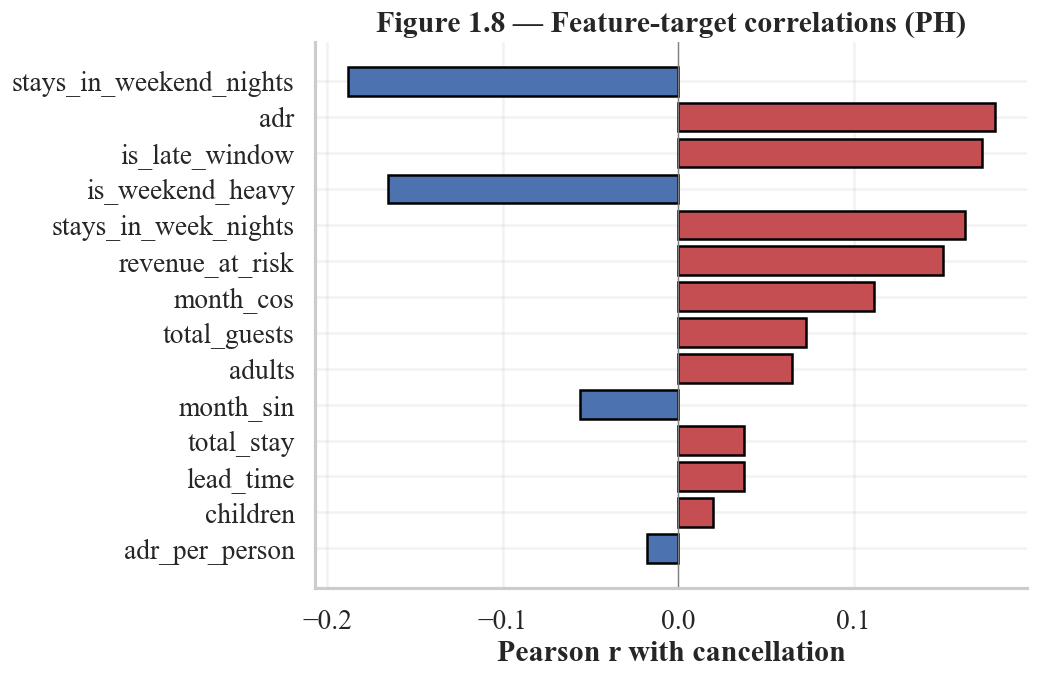

In [9]:
import numpy as np
numeric_features = [c for c in PH_BOOKING_TIME_FEATURES
                    if c != 'reserved_room_type' and pd.api.types.is_numeric_dtype(df[c])]
corrs = []
for col in numeric_features:
    r = np.corrcoef(df[col].fillna(0), df[PH_TARGET_COL])[0, 1]
    if np.isfinite(r):
        corrs.append({'feature': col, 'correlation_with_target': r})
corr_df = pd.DataFrame(corrs).sort_values('correlation_with_target',
                                          key=lambda s: s.abs(), ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#c44e52' if v >= 0 else '#4c72b0' for v in corr_df['correlation_with_target']]
ax.barh(corr_df['feature'], corr_df['correlation_with_target'], color=colors, edgecolor='black')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Pearson r with cancellation')
ax.set_title('Figure 1.8 — Feature-target correlations (PH)')
fig.tight_layout()
save_thesis_figure(fig, '1.8', 'ph_feature_target_correlations', FIG_DIR)
plt.show()

**Key Takeaway — `lead_time` and stay-length features lead**: As in Portugal,
lead time is the strongest individual numeric correlate of cancellation. The
stay-length and `revenue_at_risk` features also carry some signal. The
absolute magnitudes are smaller than Portugal because the PH dataset has fewer
rows and 16 fewer informative columns to begin with.

## 1.9 Did we accidentally include leakage columns?

Booking-time prediction means the model can only see features known at the
moment a guest books. Anything that is recorded later (reservation status,
assigned room type, booking changes after the fact) is a leakage column and
would inflate test metrics if accidentally included.

In [10]:
leakage_candidates = [
    'reservation_status', 'reservation_status_date', 'assigned_room_type',
    'booking_changes', 'days_in_waiting_list',
]
rows = [
    {'column': c, 'present_in_cleaned_df': c in df.columns, 'in_feature_list': c in PH_BOOKING_TIME_FEATURES}
    for c in leakage_candidates
]
leak_df = pd.DataFrame(rows)
leak_df.style.set_caption('Table 1.9 — Leakage-column audit').hide(axis='index')

column,present_in_cleaned_df,in_feature_list
reservation_status,False,False
reservation_status_date,False,False
assigned_room_type,False,False
booking_changes,False,False
days_in_waiting_list,False,False


**Key Takeaway — clean of leakage**: None of the canonical leakage columns
appear in the PH feature list. The reduced 16-feature engineered set is
strictly booking-time information. The perfect test metrics in notebook 02
are therefore not the result of leakage — they are the result of the dataset's archetype-based
chronological twins (§1.2), which is a property of the data source,
not a methodological mistake.